#Decision Tree Implementation


##To predict whether a passenger survived the Titanic disaster based on their personal and travel details.

###Steps to Implement :
1. Load The dataset - Titanic-Dataset [Kaggle]
2. Handle the missing Values using Mean , median and Mode
3. Remove the Unnecessary Rows and Columns
4. Use pd.get_dummies to Encode the Categorical Values into One-Hot Encoding.
5. Map the X(Input) , Y(Output) Characteristics
6. Split the data into Training and Testing Data
7. Train the Decision Tree model using the Sklearn Library
8. Find the Accuracy Score for the Model
9. Create Some Visualizations - Feature Importance , Confusion Matrix , Overfitting Analysis , Decision Tree
10. Handle the Overfitting Using the Overfitting Analysis and Pre Pruning Techniques

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("Titanic-Dataset.csv")

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())


In [8]:
df.drop("Name" , axis = 1 , inplace = True)
df.drop("Ticket" , axis = 1 , inplace = True)
df.drop("Cabin" , axis = 1 , inplace = True)

In [9]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [10]:
df = pd.get_dummies(df , columns = ["Sex" , "Embarked"])

In [11]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,2,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,3,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,4,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,5,0,3,35.0,0,0,8.0500,False,True,False,False,True


In [12]:
x = df.drop("Survived" , axis = 1)
y = df["Survived"]

In [13]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 37)

In [14]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train , y_train)

DecisionTreeClassifier()

In [15]:
y_pred = model.predict(x_test)

In [16]:
print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 0 1 1 1 1 0 1 0 0 1 1 1 0 0 0 0 1 1
 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 1 0 1 0 1 0 1 1 0 0
 1 1 0 0 0 0 1 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1 1 0 0 1 0 0 0 0
 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 1 0 1 0 1 0 0 1
 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 1 0 0 0]


In [17]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test , y_pred)
print(f"The Accuracy of this Decision Tree is : {accuracy}")

The Accuracy of this Decision Tree is : 0.7541899441340782


In [18]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,2,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,3,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,4,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,5,0,3,35.0,0,0,8.0500,False,True,False,False,True


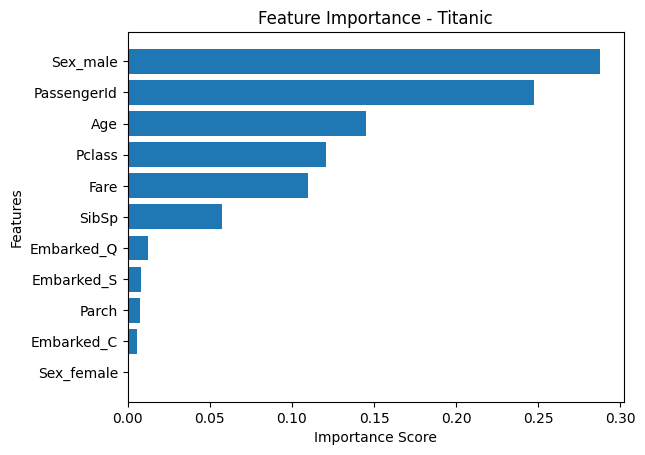

In [19]:
# Visualization - 1 : Feature Importance Graph
import matplotlib.pyplot as plt
import pandas as pd

importances = model.feature_importances_
features = x.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure()
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Titanic")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

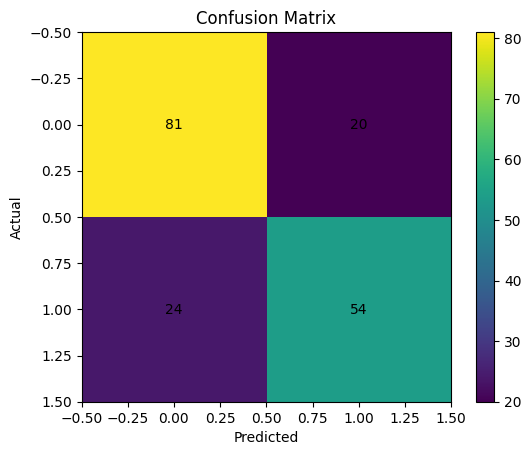

In [20]:
#Visualization - 2 : Confusion Matrix Graph
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

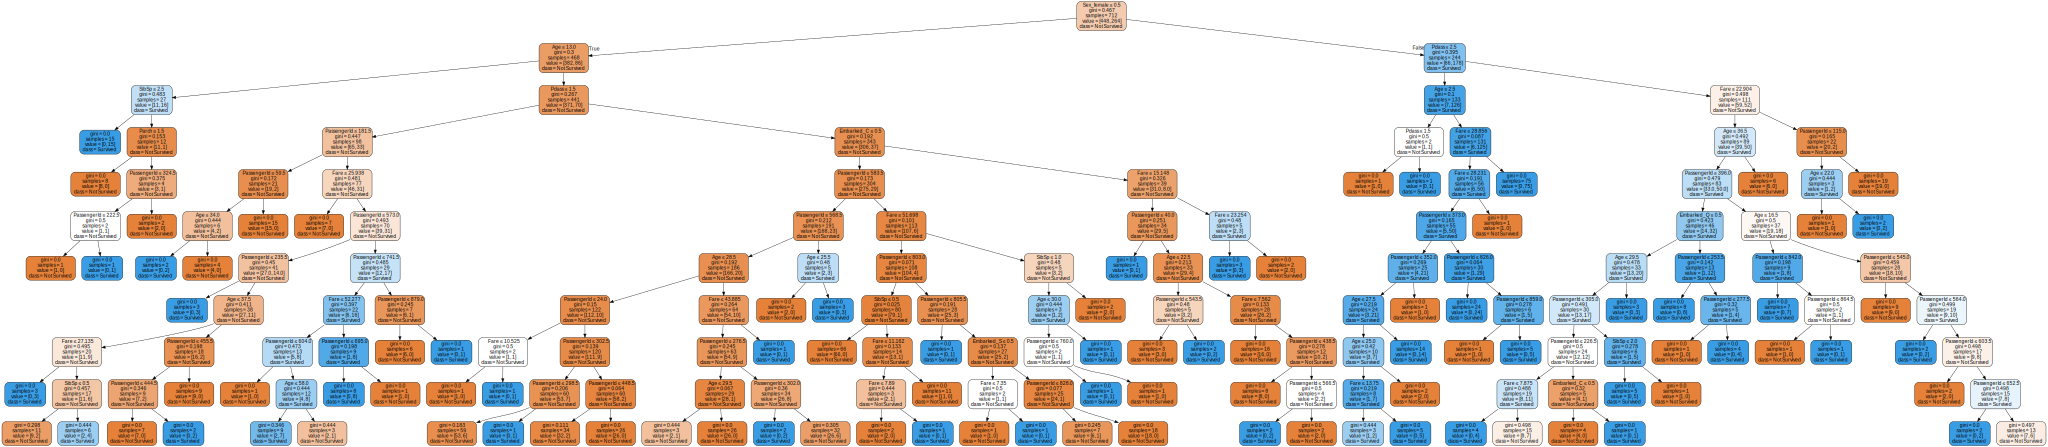

In [22]:
#Visualization - 4 : Decision Tree
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=x.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

###Handling the Overfitting

In [24]:
#Overfitting Analysis

train_acc = []
test_acc = []
depths = range(1,11)
for d in depths :
  model1 = DecisionTreeClassifier(max_depth = d , random_state = 37)
  model1.fit(x_train , y_train)
  train_acc.append(accuracy_score(y_train , model1.predict(x_train)))
  test_acc.append(accuracy_score(y_test , model1.predict(x_test)))



In [27]:
print(f"The Accuracy of Training Data at Different depths are : {train_acc}")
print(f"The Accuracy of Testing Data at Different depths are : {test_acc}")

The Accuracy of Training Data at Different depths are : [0.7865168539325843, 0.8033707865168539, 0.8328651685393258, 0.8441011235955056, 0.8497191011235955, 0.8764044943820225, 0.8946629213483146, 0.9073033707865169, 0.9269662921348315, 0.9480337078651685]
The Accuracy of Testing Data at Different depths are : [0.7877094972067039, 0.7486033519553073, 0.8212290502793296, 0.8156424581005587, 0.7877094972067039, 0.7821229050279329, 0.776536312849162, 0.7653631284916201, 0.7932960893854749, 0.7318435754189944]


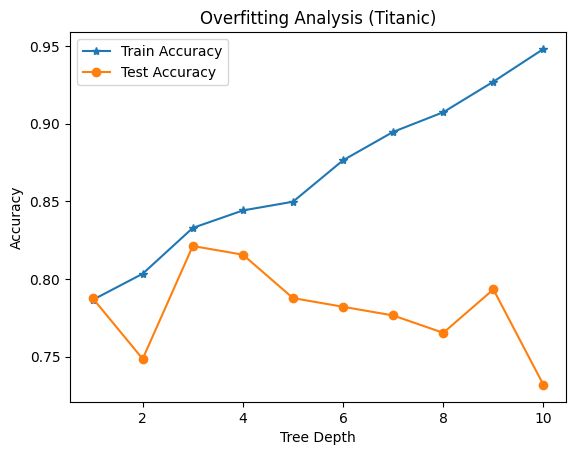

In [28]:
#Overfitting Analysis - Accuracy of model at different depths
plt.figure()
plt.plot(depths, train_acc, marker='*', label="Train Accuracy")
plt.plot(depths, test_acc, marker='o', label="Test Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis (Titanic)")
plt.legend()
plt.show()

In [33]:
#Implementation of Pre - Pruining to Handle Overfitting
model2 = DecisionTreeClassifier(
    max_depth = 4,
    min_samples_split = 10,
    min_samples_leaf = 3,
    random_state = 45
)
model2.fit(x_train , y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=3, min_samples_split=10,
                       random_state=45)

In [37]:
y_model2_pred = model2.predict(x_test)
print(y_model2_pred)

[0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0 1 1 0 1 1 1 1 0 1 0 0 1 0 0 0 0 0 0 1 1
 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 0 1 0 1 1 0 0
 1 1 0 1 1 0 1 1 1 1 1 0 0 1 0 0 0 0 0 1 0 0 1 0 0 1 1 1 0 0 0 0 1 0 0 0 0
 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 1
 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 0 0]


In [38]:
accuracy_model2 = accuracy_score(y_test , y_model2_pred)
print(f"The Accuracy of Model2 - Pre-Pruned Decision Tree is : {accuracy_model2}")

The Accuracy of Model2 - Pre-Pruned Decision Tree is : 0.8156424581005587
